In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [2]:
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

print("Classes:", class_to_idx)

class SkinLesionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df['image_path'][idx]
        image = Image.open(img_path).convert('RGB')
        label = class_to_idx[self.df['dx'][idx]]

        if self.transform:
            image = self.transform(image)

        return image, label

print("Dataset class defined")

Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Dataset class defined


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_df = pd.read_csv('../data/train.csv')
val_df = pd.read_csv('../data/val.csv')
test_df = pd.read_csv('../data/test.csv')

train_dataset = SkinLesionDataset(train_df, transform=train_transform)
val_dataset = SkinLesionDataset(val_df, transform=val_transform)
test_dataset = SkinLesionDataset(test_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Dataloaders created")
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Dataloaders created
Train batches: 251
Val batches: 32


In [4]:
model = models.resnet18(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 7)

model = model.to(device)

print("Model loaded")

Model loaded


In [5]:
class_counts = train_df['dx'].value_counts()
class_counts = class_counts.reindex(class_names)
class_weights = 1.0 / class_counts.values
class_weights = torch.FloatTensor(class_weights).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss and optimizer defined")

Class weights: tensor([0.0038, 0.0024, 0.0011, 0.0109, 0.0011, 0.0002, 0.0088],
       device='cuda:0')
Loss and optimizer defined


In [6]:
from tqdm import tqdm

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    return total_loss / len(loader), correct / len(loader.dataset)

def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    pbar = tqdm(loader, desc='Validating')
    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    return total_loss / len(loader), correct / len(loader.dataset)

In [7]:
num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = val_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '../data/best_model.pth')

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Validating: 100%|████████████████████████████████████████████████████████████████████████████████| 32/32 [00:23<00:00,  1.36it/s, loss=1.7277]


Epoch 1/10 | Train Loss: 1.6013 | Train Acc: 0.5117 | Val Loss: 1.5410 | Val Acc: 0.4985


Validating: 100%|████████████████████████████████████████████████████████████████████████████████| 32/32 [00:11<00:00,  2.75it/s, loss=1.7683]


Epoch 2/10 | Train Loss: 1.3111 | Train Acc: 0.6001 | Val Loss: 1.2810 | Val Acc: 0.6304


Validating: 100%|████████████████████████████████████████████████████████████████████████████████| 32/32 [00:11<00:00,  2.77it/s, loss=1.9153]


...

Epoch 8/10 | Train Loss: 1.0631 | Train Acc: 0.6392 | Val Loss: 1.2276 | Val Acc: 0.6094


Validating: 100%|████████████████████████████████████████████████████████████████████████████████| 32/32 [00:10<00:00,  3.01it/s, loss=1.7517]


Epoch 9/10 | Train Loss: 1.0719 | Train Acc: 0.6403 | Val Loss: 1.2279 | Val Acc: 0.6294


Validating: 100%|████████████████████████████████████████████████████████████████████████████████| 32/32 [00:10<00:00,  3.04it/s, loss=1.5925]

Epoch 10/10 | Train Loss: 1.0698 | Train Acc: 0.6359 | Val Loss: 1.1691 | Val Acc: 0.6334

Best Val Accuracy: 0.6713


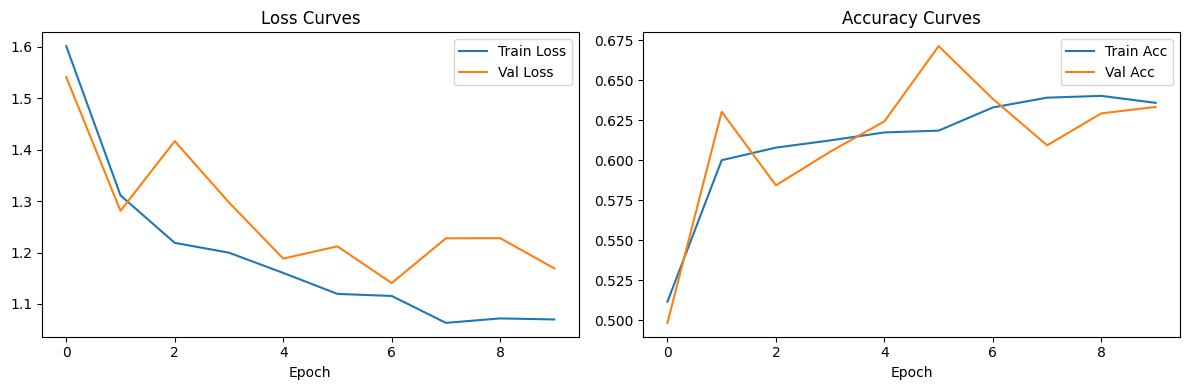

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('../data/training_curves.png')
plt.show()

In [9]:
model.load_state_dict(torch.load('../data/best_model.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

       akiec       0.33      0.41      0.37        32
         bcc       0.32      0.71      0.45        52
         bkl       0.36      0.68      0.47       110
          df       0.29      0.64      0.40        11
         mel       0.52      0.15      0.23       112
          nv       0.94      0.77      0.84       671
        vasc       0.24      0.57      0.33        14

    accuracy                           0.67      1002
   macro avg       0.43      0.56      0.44      1002
weighted avg       0.76      0.67      0.69      1002



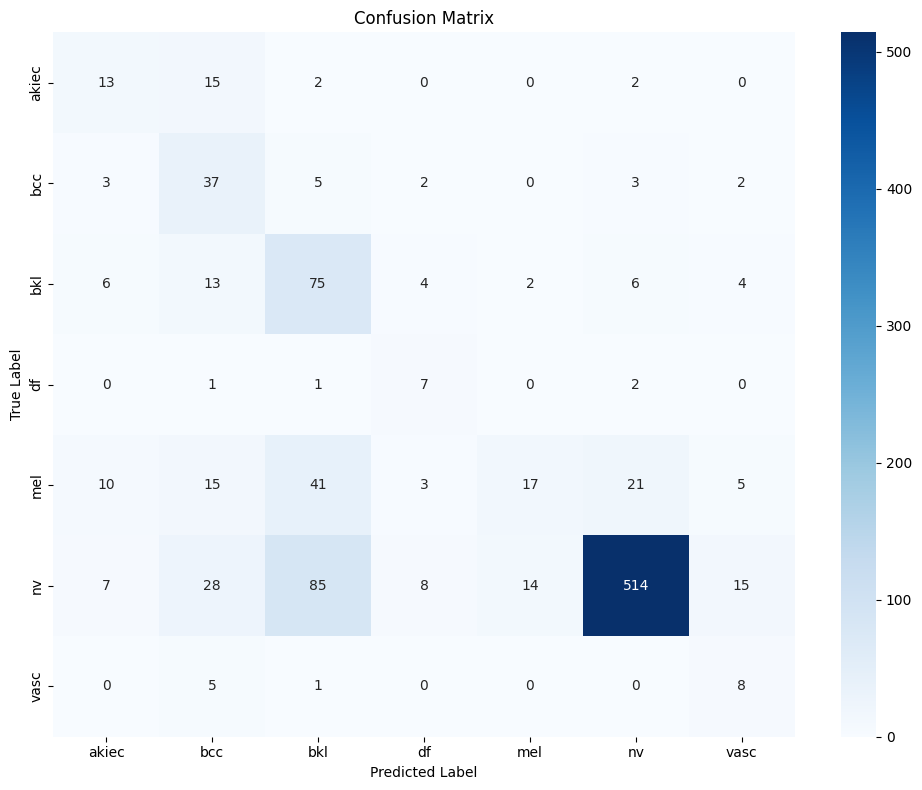

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()

In [11]:
import torch
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'class_to_idx': class_to_idx
}, '../data/skin_lesion_model.pth')

print("Saved")

Saved
